# Эксперимент 5: Feature Engineering и отбор признаков (расширенный)

В этом ноутбуке мы исследуем влияние различных наборов признаков на качество моделей LSTM.
Особенности:
- Одновременная проверка на задачу **классификации** (направление) и **регрессии** (доходность)
- **Множественные запуски** (N_RUNS) для надёжности с усреднением результатов
- **Абляция** по детальным группам признаков (технические индикаторы, волатильность, объём, макро, новости, временные и др.)
- **Корреляционный отбор** – оставляем признаки с |корреляция| > порога
- **Удаление мультиколлинеарных** признаков (корреляция между признаками > 0.95)
- **PCA** – снижение размерности
- **Лаги целевой переменной** – проверка на утечки данных (только лаги, вычисленные без заглядывания в будущее)
- **Различные горизонты прогноза** (5, 20, 200 дней)

Для всех экспериментов используем простую LSTM с фиксированными гиперпараметрами.
Результаты сохраняются в `artifacts/exp5_feature_engineering/`.

In [1]:
import sys
import json
import logging
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

# -------------------- Конфигурация --------------------
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "bigdata" / "processed"
ARTIFACTS_DIR = BASE_DIR / "artifacts" / "exp5_feature_engineering"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
SEQ_LEN = 20
BATCH_SIZE = 128
EPOCHS = 30
PATIENCE = 5
VAL_START = '2022-01-01'
TEST_START = '2023-01-01'
TOP_TICKERS = 50            # количество тикеров
N_RUNS = 3                   # количество запусков для усреднения (можно уменьшить для скорости)

# Целевые переменные
TARGET_BINARY_COL = 'target_binary_20d'
TARGET_RETURN_COL = 'target_return_20d'

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Устройство: {DEVICE}")

2026-05-23 23:25:48,584 [INFO] Устройство: cuda


In [2]:
# -------------------- Загрузка данных --------------------
df = pd.read_parquet(PROCESSED_DIR / "combined_features.parquet")
with open(PROCESSED_DIR / "feature_columns.txt") as f:
    all_feature_cols = [line.strip() for line in f if line.strip()]

# Топ-50 тикеров по объёму (для стабильности)
top_tickers = df.groupby('ticker')['volume'].mean().sort_values(ascending=False).head(TOP_TICKERS).index.tolist()
df = df[df['ticker'].isin(top_tickers)].copy()
df = df.sort_values(['date', 'ticker']).reset_index(drop=True)

logger.info(f"Загружено данных: {df.shape}, тикеров: {df['ticker'].nunique()}")
logger.info(f"Всего признаков: {len(all_feature_cols)}")

2026-05-23 23:25:49,250 [INFO] Загружено данных: (154766, 124), тикеров: 50
2026-05-23 23:25:49,251 [INFO] Всего признаков: 109


In [3]:
# -------------------- Функция create_sequences (универсальная) --------------------
def create_sequences(df, feature_cols, target_col, seq_len, test_start, val_start=None):
    X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
    for ticker in df['ticker'].unique():
        ticker_data = df[df['ticker'] == ticker].sort_values('date').copy()
        if len(ticker_data) < seq_len + 10:
            continue
        ticker_data[feature_cols] = ticker_data[feature_cols].ffill()
        ticker_data = ticker_data.dropna(subset=feature_cols + [target_col])
        if len(ticker_data) < seq_len + 1:
            continue
        
        if val_start is not None:
            train_df = ticker_data[ticker_data['date'] < val_start]
            val_df = ticker_data[(ticker_data['date'] >= val_start) & (ticker_data['date'] < test_start)]
        else:
            train_df = ticker_data[ticker_data['date'] < test_start]
            val_df = pd.DataFrame()
        test_df = ticker_data[ticker_data['date'] >= test_start].copy()
        
        if len(train_df) < seq_len + 1:
            continue
        
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_df[feature_cols])
        test_scaled = scaler.transform(test_df[feature_cols])
        train_targets = train_df[target_col].values
        test_targets = test_df[target_col].values
        
        for i in range(len(train_scaled) - seq_len):
            X_train.append(train_scaled[i:i+seq_len])
            y_train.append(train_targets[i+seq_len])
        
        if val_start is not None and len(val_df) >= seq_len + 1:
            val_scaled = scaler.transform(val_df[feature_cols])
            val_targets = val_df[target_col].values
            for i in range(len(val_scaled) - seq_len):
                X_val.append(val_scaled[i:i+seq_len])
                y_val.append(val_targets[i+seq_len])
        
        for i in range(len(test_scaled) - seq_len):
            X_test.append(test_scaled[i:i+seq_len])
            y_test.append(test_targets[i+seq_len])
    
    return (np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.float32),
            np.array(X_val, dtype=np.float32) if X_val else np.array([]),
            np.array(y_val, dtype=np.float32) if y_val else np.array([]),
            np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.float32))

In [4]:
# -------------------- Простая LSTM модель --------------------
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, num_layers=1, output_dim=1, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)
    def init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                torch.nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                torch.nn.init.orthogonal_(param)
            elif 'bias' in name:
                param.data.fill_(0.01)
        torch.nn.init.xavier_uniform_(self.fc.weight)
        if self.fc.bias is not None:
            self.fc.bias.data.fill_(0.01)

In [5]:
# -------------------- Функция обучения и оценки (с multiple runs) --------------------
def train_and_evaluate(feature_cols, target_col, problem_type, experiment_name, n_runs=N_RUNS):
    """
    problem_type: 'binary' или 'return'
    """
    logger.info(f"Эксперимент: {experiment_name}, тип: {problem_type}, число признаков: {len(feature_cols)}")
    
    # Подготовка данных (один раз, так как features и target не меняются между запусками)
    df_temp = df.dropna(subset=[target_col] + feature_cols).copy()
    X_train, y_train, X_val, y_val, X_test, y_test = create_sequences(
        df_temp, feature_cols, target_col, SEQ_LEN, TEST_START, val_start=VAL_START
    )
    if len(X_train) == 0 or len(X_test) == 0:
        logger.warning(f"Недостаточно данных для {experiment_name}")
        return None
    
    # Нормализация таргета для регрессии
    if problem_type == 'return':
        y_scaler = StandardScaler()
        y_train_norm = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        y_val_norm = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
    else:
        y_train_norm = y_train
        y_val_norm = y_val
    
    all_metrics = []
    for run in range(n_runs):
        set_seed(RANDOM_SEED + run)
        model = LSTMModel(input_dim=len(feature_cols)).to(DEVICE)
        model.init_weights()
        if problem_type == 'binary':
            criterion = nn.BCEWithLogitsLoss()
            best_metric = -np.inf   # максимизируем AUC
        else:
            criterion = nn.HuberLoss(delta=1.0)
            best_metric = float('inf')  # минимизируем loss
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)
        
        dataset = TensorDataset(torch.tensor(X_train).to(DEVICE), torch.tensor(y_train_norm).to(DEVICE))
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
        X_val_t = torch.tensor(X_val).to(DEVICE)
        y_val_t = torch.tensor(y_val_norm).to(DEVICE)
        
        best_state = None
        counter = 0
        
        for epoch in range(EPOCHS):
            model.train()
            total_loss = 0
            for batch_x, batch_y in loader:
                optimizer.zero_grad()
                pred = model(batch_x).squeeze()
                loss = criterion(pred, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()
            avg_loss = total_loss / len(loader)
            
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val_t).squeeze()
                val_loss = criterion(val_pred, y_val_t).item()
                if problem_type == 'binary':
                    val_proba = torch.sigmoid(val_pred).cpu().numpy()
                    val_auc = roc_auc_score(y_val, val_proba)
                    current_metric = val_auc
                    improved = current_metric > best_metric
                else:
                    current_metric = val_loss
                    improved = current_metric < best_metric
            
            if improved:
                best_metric = current_metric
                best_state = model.state_dict().copy()
                counter = 0
            else:
                counter += 1
                if counter >= PATIENCE:
                    logger.info(f"Ранняя остановка на эпохе {epoch+1}")
                    break
            scheduler.step(val_loss)
        
        # Тестирование
        if best_state is None:
            logger.error(f"Не удалось обучить модель для {experiment_name}, run {run}")
            continue
        model.load_state_dict(best_state)
        model.eval()
        X_test_t = torch.tensor(X_test).to(DEVICE)
        with torch.no_grad():
            y_pred = model(X_test_t).squeeze().cpu().numpy()
        
        if problem_type == 'binary':
            y_pred_proba = 1 / (1 + np.exp(-y_pred))
            y_pred_class = (y_pred_proba >= 0.5).astype(int)
            run_metrics = {
                'accuracy': accuracy_score(y_test, y_pred_class),
                'auc': roc_auc_score(y_test, y_pred_proba)
            }
        else:
            y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
            run_metrics = {
                'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
                'mae': mean_absolute_error(y_test, y_pred),
                'r2': r2_score(y_test, y_pred)
            }
        all_metrics.append(run_metrics)
    
    if not all_metrics:
        logger.error(f"Нет успешных запусков для {experiment_name}")
        return None
    
    # Усреднение
    avg_metrics = {}
    for key in all_metrics[0].keys():
        values = [m[key] for m in all_metrics]
        avg_metrics[key] = np.mean(values)
        avg_metrics[f'{key}_std'] = np.std(values)
    
    logger.info(f"Результаты {experiment_name} ({problem_type}): {avg_metrics}")
    return avg_metrics

## 0. Baseline – все признаки

In [6]:
baseline_binary = train_and_evaluate(all_feature_cols, TARGET_BINARY_COL, 'binary', 'baseline_all_features_binary')
baseline_return = train_and_evaluate(all_feature_cols, TARGET_RETURN_COL, 'return', 'baseline_all_features_return')

2026-05-23 23:25:49,298 [INFO] Эксперимент: baseline_all_features_binary, тип: binary, число признаков: 109
2026-05-23 23:26:54,615 [INFO] Ранняя остановка на эпохе 17
2026-05-23 23:27:26,696 [INFO] Ранняя остановка на эпохе 9
2026-05-23 23:27:47,448 [INFO] Ранняя остановка на эпохе 6
2026-05-23 23:27:47,537 [INFO] Результаты baseline_all_features_binary (binary): {'accuracy': np.float64(0.5299606290252838), 'accuracy_std': np.float64(0.00838778127968148), 'auc': np.float64(0.5228713115081183), 'auc_std': np.float64(0.01196229504421429)}
2026-05-23 23:27:47,594 [INFO] Эксперимент: baseline_all_features_return, тип: return, число признаков: 109
2026-05-23 23:28:50,361 [INFO] Ранняя остановка на эпохе 18
2026-05-23 23:29:24,314 [INFO] Ранняя остановка на эпохе 10
2026-05-23 23:30:04,506 [INFO] Ранняя остановка на эпохе 12
2026-05-23 23:30:04,591 [INFO] Результаты baseline_all_features_return (return): {'rmse': np.float64(0.12118335925906513), 'rmse_std': np.float64(0.0007599465276173889)

## 1. Абляция по группам признаков

Разделим признаки на детальные группы по префиксам названий.

In [7]:
# Определение групп на основе префиксов
def get_feature_groups(feature_list):
    groups = {
        # Ценовые и технические индикаторы (все SMA, EMA, RSI, MACD, BB, ATR, стохастики, моментум)
        'price_technical': [
            c for c in feature_list 
            if c.startswith(('sma_', 'ema_', 'rsi', 'macd', 'bb_', 'atr', 
                             'stoch', 'williams', 'cci', 'momentum', 'roc_', 
                             'rolling_max', 'drawdown', 'intraday', 'upper_shadow', 
                             'lower_shadow', 'body_size', 'price_sma', 'sma_20_50_cross', 
                             'sma_50_200_cross', 'price_above_sma', 'macd_bullish'))
        ],
        # Волатильность
        'volatility': [
            c for c in feature_list 
            if c.startswith(('volatility', 'parkinson', 'atr'))  # ATR уже включена выше, можно убрать дублирование
        ],
        # Объём
        'volume': [
            c for c in feature_list 
            if c.startswith(('vol_ma', 'vol_ratio', 'volume_lag', 'volume_change', 'obv'))
        ],
        # Лаги цены (логические возвраты и close)
        'price_lags': [
            c for c in feature_list 
            if c.startswith(('close_lag', 'log_ret_lag'))
        ],
        # Макроэкономика + курс рубля
        'macro': [
            c for c in feature_list 
            if c.startswith(('macro_', 'usd_rub', 'm2_growth', 'real_rate'))
        ],
        # Новости
        'news': [
            c for c in feature_list 
            if c.startswith('news_')
        ],
        # Временные признаки
        'temporal': [
            c for c in feature_list 
            if c.startswith(('day_of', 'month', 'quarter', 'week_of', 'days_', 'is_'))
        ],
        # Рыночные (бенчмарк, относительные)
        'market': [
            c for c in feature_list 
            if c.startswith(('market_', 'relative_'))
        ]
    }
    groups = {k: list(set(v)) for k, v in groups.items() if v}
    return groups

feature_groups = get_feature_groups(all_feature_cols)
logger.info(f"Обнаружено групп: {list(feature_groups.keys())}")

# Для абляции: удаляем каждую группу и обучаем на остальных
ablation_results_binary = {}
ablation_results_return = {}

for group_name, group_feats in feature_groups.items():
    remaining_feats = [f for f in all_feature_cols if f not in group_feats]
    if len(remaining_feats) == 0:
        continue
    logger.info(f"Абляция группы: {group_name} (удалено {len(group_feats)} признаков)")
    res_bin = train_and_evaluate(remaining_feats, TARGET_BINARY_COL, 'binary', f'ablation_{group_name}_binary')
    res_ret = train_and_evaluate(remaining_feats, TARGET_RETURN_COL, 'return', f'ablation_{group_name}_return')
    ablation_results_binary[group_name] = res_bin
    ablation_results_return[group_name] = res_ret

2026-05-23 23:30:04,660 [INFO] Обнаружено групп: ['price_technical', 'volatility', 'volume', 'price_lags', 'macro', 'news', 'temporal', 'market']
2026-05-23 23:30:04,661 [INFO] Абляция группы: price_technical (удалено 32 признаков)
2026-05-23 23:30:04,662 [INFO] Эксперимент: ablation_price_technical_binary, тип: binary, число признаков: 77
2026-05-23 23:30:32,238 [INFO] Ранняя остановка на эпохе 7
2026-05-23 23:31:08,032 [INFO] Ранняя остановка на эпохе 10
2026-05-23 23:31:37,041 [INFO] Ранняя остановка на эпохе 8
2026-05-23 23:31:37,122 [INFO] Результаты ablation_price_technical_binary (binary): {'accuracy': np.float64(0.5412380892282451), 'accuracy_std': np.float64(0.016046396110352558), 'auc': np.float64(0.5692789797136671), 'auc_std': np.float64(0.01674043236583874)}
2026-05-23 23:31:37,163 [INFO] Эксперимент: ablation_price_technical_return, тип: return, число признаков: 77
2026-05-23 23:32:37,975 [INFO] Ранняя остановка на эпохе 17
2026-05-23 23:33:07,162 [INFO] Ранняя остановка 

**Анализ абляции групп признаков:**

- Удаление **price_technical** (все SMA, EMA, RSI, MACD, Bollinger Bands, ATR, стохастики, моментум и др.) повышает AUC с 0.523 до **0.569**. Это говорит о том, что технические индикаторы вносят шум при прогнозе направления на 20 дней. Возможно, они сильно коррелируют между собой или содержат избыточную информацию.
- Удаление **temporal** (день недели, месяц, квартал и т.п.) даёт AUC **0.571** – наилучший результат в абляции. Временные признаки, вероятно, не имеют устойчивой связи с будущим направлением.
- Удаление **macro** (макроэкономические показатели) резко ухудшает AUC до 0.480, что указывает на важность этой группы для классификации.
- Удаление **news** (новостные признаки) также снижает качество (AUC 0.508), но менее критично.
- Для **регрессии** удаление `price_technical` сильно ухудшает R² (до -0.331), тогда как удаление `macro` или `volume` почти не влияет. Это означает, что для предсказания величины доходности технические индикаторы необходимы, а макрофакторы менее значимы.

**Вывод:** Для задачи бинарной классификации целесообразно **исключить** группы `price_technical` и `temporal`, а для регрессии – оставить `price_technical`. Остальные группы (macro, news, volume, market, price_lags) полезны.

## 2. Корреляционный отбор признаков (с целевой переменной)

Оставляем признаки с |корреляция| > threshold на тренировочном периоде.

In [8]:
corr_threshold = 0.03
df_corr = df.dropna(subset=[TARGET_BINARY_COL] + all_feature_cols)
train_corr = df_corr[df_corr['date'] < VAL_START]
correlations = train_corr[all_feature_cols].corrwith(train_corr[TARGET_BINARY_COL]).abs()
selected_corr = correlations[correlations > corr_threshold].index.tolist()
logger.info(f"Корреляционный отбор: {len(selected_corr)} признаков из {len(all_feature_cols)}")

corr_binary = train_and_evaluate(selected_corr, TARGET_BINARY_COL, 'binary', 'correlation_filter_binary')
corr_return = train_and_evaluate(selected_corr, TARGET_RETURN_COL, 'return', 'correlation_filter_return')

2026-05-23 23:59:29,601 [INFO] Корреляционный отбор: 21 признаков из 109
2026-05-23 23:59:29,602 [INFO] Эксперимент: correlation_filter_binary, тип: binary, число признаков: 21
2026-05-24 00:00:01,252 [INFO] Ранняя остановка на эпохе 8
2026-05-24 00:00:37,364 [INFO] Ранняя остановка на эпохе 10
2026-05-24 00:00:59,116 [INFO] Ранняя остановка на эпохе 6
2026-05-24 00:00:59,170 [INFO] Результаты correlation_filter_binary (binary): {'accuracy': np.float64(0.5613344001969595), 'accuracy_std': np.float64(0.02801605765327363), 'auc': np.float64(0.5609526078622343), 'auc_std': np.float64(0.03131439701441221)}
2026-05-24 00:00:59,188 [INFO] Эксперимент: correlation_filter_return, тип: return, число признаков: 21
2026-05-24 00:01:31,637 [INFO] Ранняя остановка на эпохе 9
2026-05-24 00:02:13,015 [INFO] Ранняя остановка на эпохе 12
2026-05-24 00:02:33,967 [INFO] Ранняя остановка на эпохе 6
2026-05-24 00:02:34,020 [INFO] Результаты correlation_filter_return (return): {'rmse': np.float64(0.12313461

**Анализ корреляционного отбора:**

Отобрано 21 признак с абсолютной корреляцией с целевой бинарной переменной > 0.03.  
Результат: AUC = **0.561**, что немного выше baseline (0.523) и сопоставимо с лучшими результатами абляции (0.569, 0.571).  
Это говорит о том, что даже небольшое количество признаков, имеющих прямую линейную связь с направлением, может дать приемлемое качество. Корреляционный отбор эффективно уменьшает размерность и упрощает модель без значительной потери точности.

## 3. Удаление мультиколлинеарных признаков (корреляция > 0.95)

Оставляем по одному признаку из группы сильно коррелирующих.

In [9]:
def remove_highly_correlated(features, df_data, threshold=0.95):
    X = df_data[features].dropna().values
    corr_matrix = np.corrcoef(X.T)
    upper_tri = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    high_corr_pairs = np.where((corr_matrix > threshold) & upper_tri)
    to_remove = set()
    for i, j in zip(*high_corr_pairs):
        to_remove.add(features[j])
    return [f for f in features if f not in to_remove]

# Используем тренировочные данные для расчёта корреляции
df_temp = df.dropna(subset=all_feature_cols)
train_corr_data = df_temp[df_temp['date'] < VAL_START]
selected_no_multicoll = remove_highly_correlated(all_feature_cols, train_corr_data, threshold=0.95)
logger.info(f"После удаления мультиколлинеарности: {len(selected_no_multicoll)} признаков")

multicoll_binary = train_and_evaluate(selected_no_multicoll, TARGET_BINARY_COL, 'binary', 'no_multicoll_binary')
multicoll_return = train_and_evaluate(selected_no_multicoll, TARGET_RETURN_COL, 'return', 'no_multicoll_return')

2026-05-24 00:02:34,322 [INFO] После удаления мультиколлинеарности: 84 признаков
2026-05-24 00:02:34,323 [INFO] Эксперимент: no_multicoll_binary, тип: binary, число признаков: 84
2026-05-24 00:03:00,058 [INFO] Ранняя остановка на эпохе 7
2026-05-24 00:03:40,702 [INFO] Ранняя остановка на эпохе 12
2026-05-24 00:04:04,501 [INFO] Ранняя остановка на эпохе 7
2026-05-24 00:04:04,573 [INFO] Результаты no_multicoll_binary (binary): {'accuracy': np.float64(0.5198106551967411), 'accuracy_std': np.float64(0.035451098527926314), 'auc': np.float64(0.5417504222575772), 'auc_std': np.float64(0.04250981398754409)}
2026-05-24 00:04:04,616 [INFO] Эксперимент: no_multicoll_return, тип: return, число признаков: 84
2026-05-24 00:04:45,945 [INFO] Ранняя остановка на эпохе 12
2026-05-24 00:05:18,759 [INFO] Ранняя остановка на эпохе 10
2026-05-24 00:05:43,528 [INFO] Ранняя остановка на эпохе 7
2026-05-24 00:05:43,594 [INFO] Результаты no_multicoll_return (return): {'rmse': np.float64(0.11933152290930983), 'r

**Анализ удаления мультиколлинеарных признаков:**

После удаления признаков с парной корреляцией > 0.95 остаётся 84 признака.  
Качество классификации (AUC = 0.542) практически не изменилось по сравнению с baseline (0.523), но и не улучшилось.  
Устранение сильной корреляции между признаками не принесло пользы, возможно, из-за того, что LSTM способен самостоятельно справляться с коллинеарностью через свои веса.

## 4. PCA

Применяем PCA к признакам (после стандартизации) на тренировочных данных, сохраняя 95% дисперсии.

In [10]:
# Создадим PCA трансформер
df_temp = df.dropna(subset=all_feature_cols)
train_pca = df_temp[df_temp['date'] < VAL_START]
X_train_pca_raw = train_pca[all_feature_cols].values
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_train_pca_raw)
pca = PCA(n_components=0.95)
pca.fit(X_scaled)
logger.info(f"PCA: {pca.n_components_} компонент, объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.4f}")

# Функция для трансформации новых данных
def transform_pca(df_part, scaler, pca):
    X = df_part[all_feature_cols].values
    X_scaled = scaler.transform(X)
    return pca.transform(X_scaled)

# Создание последовательностей в PCA-пространстве
def create_pca_sequences(df, target_col, seq_len, test_start, val_start, scaler, pca):
    X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
    for ticker in df['ticker'].unique():
        ticker_data = df[df['ticker'] == ticker].sort_values('date').copy()
        if len(ticker_data) < seq_len + 10: continue
        ticker_data = ticker_data.dropna(subset=all_feature_cols + [target_col])
        if len(ticker_data) < seq_len + 1: continue
        
        train_df = ticker_data[ticker_data['date'] < val_start]
        val_df = ticker_data[(ticker_data['date'] >= val_start) & (ticker_data['date'] < test_start)]
        test_df = ticker_data[ticker_data['date'] >= test_start].copy()
        if len(train_df) < seq_len + 1: continue
        
        train_pca_vals = transform_pca(train_df, scaler, pca)
        val_pca_vals = transform_pca(val_df, scaler, pca) if len(val_df) >= seq_len + 1 else None
        test_pca_vals = transform_pca(test_df, scaler, pca)
        
        train_targets = train_df[target_col].values
        test_targets = test_df[target_col].values
        
        for i in range(len(train_pca_vals) - seq_len):
            X_train.append(train_pca_vals[i:i+seq_len])
            y_train.append(train_targets[i+seq_len])
        
        if val_pca_vals is not None:
            val_targets = val_df[target_col].values
            for i in range(len(val_pca_vals) - seq_len):
                X_val.append(val_pca_vals[i:i+seq_len])
                y_val.append(val_targets[i+seq_len])
        
        for i in range(len(test_pca_vals) - seq_len):
            X_test.append(test_pca_vals[i:i+seq_len])
            y_test.append(test_targets[i+seq_len])
    
    return (np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.float32),
            np.array(X_val, dtype=np.float32) if X_val else np.array([]),
            np.array(y_val, dtype=np.float32) if y_val else np.array([]),
            np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.float32))

# Подготовка PCA-данных и обучение
def train_pca_model(target_col, problem_type, experiment_suffix):
    X_train, y_train, X_val, y_val, X_test, y_test = create_pca_sequences(
        df, target_col, SEQ_LEN, TEST_START, VAL_START, scaler_pca, pca
    )
    if len(X_train) == 0:
        return None
    # Нормализация таргета для регрессии
    if problem_type == 'return':
        y_scaler = StandardScaler()
        y_train_norm = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        y_val_norm = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
    else:
        y_train_norm = y_train
        y_val_norm = y_val
    
    all_metrics = []
    for run in range(N_RUNS):
        set_seed(RANDOM_SEED + run)
        model = LSTMModel(input_dim=pca.n_components_).to(DEVICE)
        model.init_weights()
        if problem_type == 'binary':
            criterion = nn.BCEWithLogitsLoss()
            best_metric = -np.inf
        else:
            criterion = nn.HuberLoss(delta=1.0)
            best_metric = float('inf')
        optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)
        
        dataset = TensorDataset(torch.tensor(X_train).to(DEVICE), torch.tensor(y_train_norm).to(DEVICE))
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
        X_val_t = torch.tensor(X_val).to(DEVICE)
        y_val_t = torch.tensor(y_val_norm).to(DEVICE)
        
        best_state = None
        counter = 0
        for epoch in range(EPOCHS):
            model.train()
            total_loss = 0
            for batch_x, batch_y in loader:
                optimizer.zero_grad()
                pred = model(batch_x).squeeze()
                loss = criterion(pred, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()
            avg_loss = total_loss / len(loader)
            
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val_t).squeeze()
                val_loss = criterion(val_pred, y_val_t).item()
                if problem_type == 'binary':
                    val_proba = torch.sigmoid(val_pred).cpu().numpy()
                    val_auc = roc_auc_score(y_val, val_proba)
                    current_metric = val_auc
                    improved = current_metric > best_metric
                else:
                    current_metric = val_loss
                    improved = current_metric < best_metric
            
            if improved:
                best_metric = current_metric
                best_state = model.state_dict().copy()
                counter = 0
            else:
                counter += 1
                if counter >= PATIENCE:
                    logger.info(f"PCA ранняя остановка на эпохе {epoch+1}")
                    break
            scheduler.step(val_loss)
        
        if best_state is None:
            logger.error(f"Не удалось обучить PCA модель для {experiment_suffix}, run {run}")
            continue
        model.load_state_dict(best_state)
        model.eval()
        X_test_t = torch.tensor(X_test).to(DEVICE)
        with torch.no_grad():
            y_pred = model(X_test_t).squeeze().cpu().numpy()
        if problem_type == 'binary':
            y_pred_proba = 1 / (1 + np.exp(-y_pred))
            y_pred_class = (y_pred_proba >= 0.5).astype(int)
            run_metrics = {'accuracy': accuracy_score(y_test, y_pred_class), 'auc': roc_auc_score(y_test, y_pred_proba)}
        else:
            y_pred = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
            run_metrics = {'rmse': np.sqrt(mean_squared_error(y_test, y_pred)), 'mae': mean_absolute_error(y_test, y_pred), 'r2': r2_score(y_test, y_pred)}
        all_metrics.append(run_metrics)
    
    if not all_metrics:
        return None
    avg_metrics = {}
    for key in all_metrics[0].keys():
        values = [m[key] for m in all_metrics]
        avg_metrics[key] = np.mean(values)
        avg_metrics[f'{key}_std'] = np.std(values)
    logger.info(f"PCA {experiment_suffix}: {avg_metrics}")
    return avg_metrics

pca_binary = train_pca_model(TARGET_BINARY_COL, 'binary', 'binary')
pca_return = train_pca_model(TARGET_RETURN_COL, 'return', 'return')

2026-05-24 00:05:44,118 [INFO] PCA: 45 компонент, объяснённая дисперсия: 0.9529
2026-05-24 00:06:32,117 [INFO] PCA ранняя остановка на эпохе 14
2026-05-24 00:06:58,745 [INFO] PCA ранняя остановка на эпохе 8
2026-05-24 00:07:25,783 [INFO] PCA ранняя остановка на эпохе 8
2026-05-24 00:07:25,833 [INFO] PCA binary: {'accuracy': np.float64(0.5266379918527115), 'accuracy_std': np.float64(0.03760308506492971), 'auc': np.float64(0.5441029276163829), 'auc_std': np.float64(0.05522001848304095)}
2026-05-24 00:07:56,925 [INFO] PCA ранняя остановка на эпохе 9
2026-05-24 00:08:23,014 [INFO] PCA ранняя остановка на эпохе 8
2026-05-24 00:09:38,633 [INFO] PCA ранняя остановка на эпохе 23
2026-05-24 00:09:38,678 [INFO] PCA return: {'rmse': np.float64(0.11524088598615613), 'rmse_std': np.float64(0.0019967578262972898), 'mae': np.float64(0.07739270726839702), 'mae_std': np.float64(0.0016782660127564674), 'r2': np.float64(-0.043299357096354164), 'r2_std': np.float64(0.03609170052152217)}


**Анализ PCA:**

Снижение размерности до 45 главных компонент (95% дисперсии) дало AUC = 0.544 – близко к baseline.  
Для регрессии R² улучшился с -0.153 до -0.043, что всё ещё отрицательно, но свидетельствует о небольшом выигрыше.  
PCA не стал прорывом, возможно, из-за нелинейного характера зависимостей в данных.

## 5. Лаги целевой переменной (с осторожностью – проверка на утечки)

Добавляем лаги целевой переменной, но только те, которые вычисляются без заглядывания в будущее (т.е. на основе исторических данных).
**Важно:** при создании последовательностей мы используем информацию только из прошлого, поэтому утечки нет.
Однако нужно убедиться, что в процессе формирования последовательностей лаги берутся из предыдущих дней (это обеспечивается сдвигом).

Дополнительно проверим, не приводит ли это к неестественному улучшению. Если AUC подскакивает слишком сильно – возможно, модель просто запоминает автокорреляцию.
Для чистоты эксперимента мы также можем обучить модель только на лагах целевой переменной, чтобы оценить их предсказательную силу.

In [11]:
lags = [1, 2, 5, 10]
# Создадим признаки лагов
df_lags = df.copy()
for lag in lags:
    df_lags[f'target_lag_{lag}'] = df_lags.groupby('ticker')[TARGET_BINARY_COL].shift(lag)
new_features = all_feature_cols + [f'target_lag_{lag}' for lag in lags]
df_lags = df_lags.dropna(subset=new_features + [TARGET_BINARY_COL, TARGET_RETURN_COL])
# Временно подменяем глобальный df для экспериментов с лагами
original_df = df
df = df_lags

lag_binary = train_and_evaluate(new_features, TARGET_BINARY_COL, 'binary', 'with_target_lags_binary')
lag_return = train_and_evaluate(new_features, TARGET_RETURN_COL, 'return', 'with_target_lags_return')

# Восстанавливаем df
df = original_df

2026-05-24 00:09:38,930 [INFO] Эксперимент: with_target_lags_binary, тип: binary, число признаков: 113
2026-05-24 00:10:18,225 [INFO] Ранняя остановка на эпохе 11
2026-05-24 00:10:48,077 [INFO] Ранняя остановка на эпохе 9
2026-05-24 00:11:15,011 [INFO] Ранняя остановка на эпохе 8
2026-05-24 00:11:15,103 [INFO] Результаты with_target_lags_binary (binary): {'accuracy': np.float64(0.7643872390402914), 'accuracy_std': np.float64(0.022728462532829584), 'auc': np.float64(0.8641826056988401), 'auc_std': np.float64(0.011665207910253494)}
2026-05-24 00:11:15,163 [INFO] Эксперимент: with_target_lags_return, тип: return, число признаков: 113
2026-05-24 00:12:04,839 [INFO] Ранняя остановка на эпохе 14
2026-05-24 00:13:14,480 [INFO] Ранняя остановка на эпохе 21
2026-05-24 00:14:25,416 [INFO] Ранняя остановка на эпохе 21
2026-05-24 00:14:25,465 [INFO] Результаты with_target_lags_return (return): {'rmse': np.float64(0.10726303578226241), 'rmse_std': np.float64(0.002320876246138243), 'mae': np.float64

In [17]:
lags = [1, 2, 5, 10]
# Создадим признаки лагов
df_lags = df.copy()
for lag in lags:
    df_lags[f'target_lag_{lag}'] = df_lags.groupby('ticker')[TARGET_BINARY_COL].shift(lag)
new_features = all_feature_cols + [f'target_lag_{lag}' for lag in lags]
df_lags = df_lags.dropna(subset=new_features + [TARGET_BINARY_COL, TARGET_RETURN_COL])
# Временно подменяем глобальный df для экспериментов с лагами
original_df = df
df = df_lags
# Диагностика автокорреляции целевой переменной
# Используем тренировочный период для оценки
df_diag = df[df['date'] < VAL_START].copy()
# Группируем по тикеру
autocorr_list = []
for ticker, grp in df_diag.groupby('ticker'):
    grp = grp.sort_values('date')
    # Берём не более 1000 точек для скорости
    if len(grp) > 1000:
        grp = grp.iloc[-1000:]
    if len(grp) > 2:
        aut = grp[TARGET_BINARY_COL].autocorr(lag=1)
        autocorr_list.append(aut)
print(f"Средняя автокорреляция (lag=1) по тикерам: {np.mean(autocorr_list):.4f}")
# Для регрессии
autocorr_ret = []
for ticker, grp in df_diag.groupby('ticker'):
    grp = grp.sort_values('date')
    if len(grp) > 1000:
        grp = grp.iloc[-1000:]
    if len(grp) > 2:
        aut = grp[TARGET_RETURN_COL].autocorr(lag=1)
        autocorr_ret.append(aut)
print(f"Средняя автокорреляция возврата (lag=1): {np.mean(autocorr_ret):.4f}")

# Эксперимент: только лаги целевой переменной (без других признаков)
lag_features_only = [f'target_lag_{lag}' for lag in lags]
if all(col in df_lags.columns for col in lag_features_only):
    lag_only_binary = train_and_evaluate(lag_features_only, TARGET_BINARY_COL, 'binary', 'only_target_lags_binary')
    lag_only_return = train_and_evaluate(lag_features_only, TARGET_RETURN_COL, 'return', 'only_target_lags_return')
    print("Только лаги (бинарный):", lag_only_binary)
    print("Только лаги (регрессия):", lag_only_return)

# Persistence модель: предсказываем, что target = target_lag_1
df_temp = df.dropna(subset=[TARGET_BINARY_COL] + [f'target_lag_1'])
X_tr, y_tr, X_val, y_val, X_test, y_test = create_sequences(
    df_temp, [f'target_lag_1'], TARGET_BINARY_COL, SEQ_LEN, TEST_START, val_start=VAL_START
)
# Для теста: просто берём последний элемент последовательности как предсказание
# Но проще: из тестовых последовательностей извлечь последний признак
persist_auc = []
for seq in X_test:
    # seq имеет форму (SEQ_LEN, 1), последнее значение – target_lag_1 для следующего дня
    pred = seq[-1, 0]  # это значение target_lag_1, которое равно true target за предыдущий день
    # Но для оценки нужно предсказание на день i+SEQ_LEN. В нашей последовательности первый элемент – lag_1 для дня i+1?
    # Проще: в тестовых y_test – истинные значения. Предсказание = значение target_lag_1, которое было доступно.
    # Нам нужно сопоставить. Создадим отдельную простую проверку без LSTM.
    pass
# Более простой способ: сравнить baseline "предсказываем лаг 1" на тесте
test_df = df[df['date'] >= TEST_START].copy()
test_df['pred'] = test_df.groupby('ticker')[TARGET_BINARY_COL].shift(1)
test_df = test_df.dropna(subset=[TARGET_BINARY_COL, 'pred'])
auc_persist = roc_auc_score(test_df[TARGET_BINARY_COL], test_df['pred'])
print(f"AUC persistence (предсказание = лаг 1): {auc_persist:.4f}")

df = original_df

2026-05-24 00:40:31,638 [INFO] Эксперимент: only_target_lags_binary, тип: binary, число признаков: 4


Средняя автокорреляция (lag=1) по тикерам: nan
Средняя автокорреляция возврата (lag=1): 0.9113


2026-05-24 00:41:28,841 [INFO] Ранняя остановка на эпохе 17
2026-05-24 00:42:11,712 [INFO] Ранняя остановка на эпохе 13
2026-05-24 00:42:54,743 [INFO] Ранняя остановка на эпохе 13
2026-05-24 00:42:54,774 [INFO] Результаты only_target_lags_binary (binary): {'accuracy': np.float64(0.8773759018240215), 'accuracy_std': np.float64(0.000532731976004721), 'auc': np.float64(0.91091719080794), 'auc_std': np.float64(0.0005535294510162146)}
2026-05-24 00:42:54,782 [INFO] Эксперимент: only_target_lags_return, тип: return, число признаков: 4
2026-05-24 00:44:06,420 [INFO] Ранняя остановка на эпохе 22
2026-05-24 00:45:17,356 [INFO] Ранняя остановка на эпохе 22
2026-05-24 00:46:12,343 [INFO] Ранняя остановка на эпохе 17
2026-05-24 00:46:12,370 [INFO] Результаты only_target_lags_return (return): {'rmse': np.float64(0.08918038450909031), 'rmse_std': np.float64(0.0008675958331994582), 'mae': np.float64(0.05371404935916265), 'mae_std': np.float64(0.00034353492334628235), 'r2': np.float64(0.37533787886301

Только лаги (бинарный): {'accuracy': np.float64(0.8773759018240215), 'accuracy_std': np.float64(0.000532731976004721), 'auc': np.float64(0.91091719080794), 'auc_std': np.float64(0.0005535294510162146)}
Только лаги (регрессия): {'rmse': np.float64(0.08918038450909031), 'rmse_std': np.float64(0.0008675958331994582), 'mae': np.float64(0.05371404935916265), 'mae_std': np.float64(0.00034353492334628235), 'r2': np.float64(0.3753378788630168), 'r2_std': np.float64(0.012171210451149491)}
AUC persistence (предсказание = лаг 1): 0.9163


**Анализ лагов целевой переменной:**

Добавление 4 лагов бинарного таргета (`target_lag_1,2,5,10`) привело к резкому скачку AUC до **0.864**.  
Однако это связано с **высокой автокорреляцией** целевой переменной: средняя автокорреляция возврата (lag=1) составляет **0.911**.  
Модель «предсказание = предыдущее значение» (persistence) даёт AUC = **0.916**, что почти совпадает с результатом LSTM.  
Следовательно, LSTM не выучил ничего сверх тривиального правила «завтра будет как сегодня».  
**Вывод:** Лаги целевой переменной создают иллюзию высокой точности, но бесполезны для реального прогнозирования, так как просто копируют инерцию рынка. **Не использовать их в финальной модели.**

## 6. Различные горизонты прогноза (5, 20, 200 дней)

Создаём целевые переменные для разных горизонтов и повторяем baseline.

In [12]:
horizons = [5, 20, 200]
horizon_results_binary = {}
horizon_results_return = {}

for h in horizons:
    # Создаём временные целевые колонки
    target_bin = f'target_binary_{h}d'
    target_ret = f'target_return_{h}d'
    if target_bin not in df.columns or target_ret not in df.columns:
        logger.warning(f"Целевые переменные для горизонта {h} не найдены, пропускаем")
        continue
    logger.info(f"Горизонт {h}: обучение...")
    res_bin = train_and_evaluate(all_feature_cols, target_bin, 'binary', f'horizon_{h}_binary')
    res_ret = train_and_evaluate(all_feature_cols, target_ret, 'return', f'horizon_{h}_return')
    horizon_results_binary[h] = res_bin
    horizon_results_return[h] = res_ret

2026-05-24 00:14:25,533 [INFO] Горизонт 5: обучение...
2026-05-24 00:14:25,533 [INFO] Эксперимент: horizon_5_binary, тип: binary, число признаков: 109
2026-05-24 00:14:51,654 [INFO] Ранняя остановка на эпохе 7
2026-05-24 00:15:12,382 [INFO] Ранняя остановка на эпохе 6
2026-05-24 00:15:40,631 [INFO] Ранняя остановка на эпохе 8
2026-05-24 00:15:40,720 [INFO] Результаты horizon_5_binary (binary): {'accuracy': np.float64(0.5158507999362781), 'accuracy_std': np.float64(0.014448633203387204), 'auc': np.float64(0.5177187862589016), 'auc_std': np.float64(0.0172312621179166)}
2026-05-24 00:15:40,776 [INFO] Эксперимент: horizon_5_return, тип: return, число признаков: 109
2026-05-24 00:16:03,041 [INFO] Ранняя остановка на эпохе 6
2026-05-24 00:16:42,438 [INFO] Ранняя остановка на эпохе 12
2026-05-24 00:17:16,172 [INFO] Ранняя остановка на эпохе 10
2026-05-24 00:17:16,261 [INFO] Результаты horizon_5_return (return): {'rmse': np.float64(0.06437892664072813), 'rmse_std': np.float64(0.001044100101094

**Анализ горизонтов прогноза:**

- Горизонт **5 дней**: AUC = 0.518 – хуже, чем на 20 днях. Короткий горизонт более шумный?
- Горизонт **20 дней**: базовый AUC = 0.523.
- Горизонт **200 дней**: AUC = 0.564 – немного выше, но с большим стандартным отклонением (0.053).  
  Возможно, на длинных горизонтах влияние шума усредняется, но статистическая значимость невысока.

**Вывод:** Оптимальным остаётся горизонт 20 дней, используемый в большинстве экспериментов.

## Сбор и визуализация результатов

Сведём все метрики в таблицы для сравнения.

Binary classification results:
                                   accuracy  accuracy_std     auc  auc_std
Baseline                            0.5300        0.0084  0.5229   0.0120
Correlation filter                  0.5613        0.0280  0.5610   0.0313
No multicollinearity                0.5198        0.0355  0.5418   0.0425
PCA                                 0.5266        0.0376  0.5441   0.0552
With target lags                    0.7644        0.0227  0.8642   0.0117
Ablation: remove price_technical    0.5412        0.0160  0.5693   0.0167
Ablation: remove volatility         0.5217        0.0124  0.5427   0.0172
Ablation: remove volume             0.5196        0.0349  0.5202   0.0508
Ablation: remove price_lags         0.5361        0.0165  0.5292   0.0360
Ablation: remove macro              0.5044        0.0175  0.4799   0.0114
Ablation: remove news               0.5128        0.0235  0.5076   0.0259
Ablation: remove temporal           0.5542        0.0172  0.5709   0.0216
Ablati

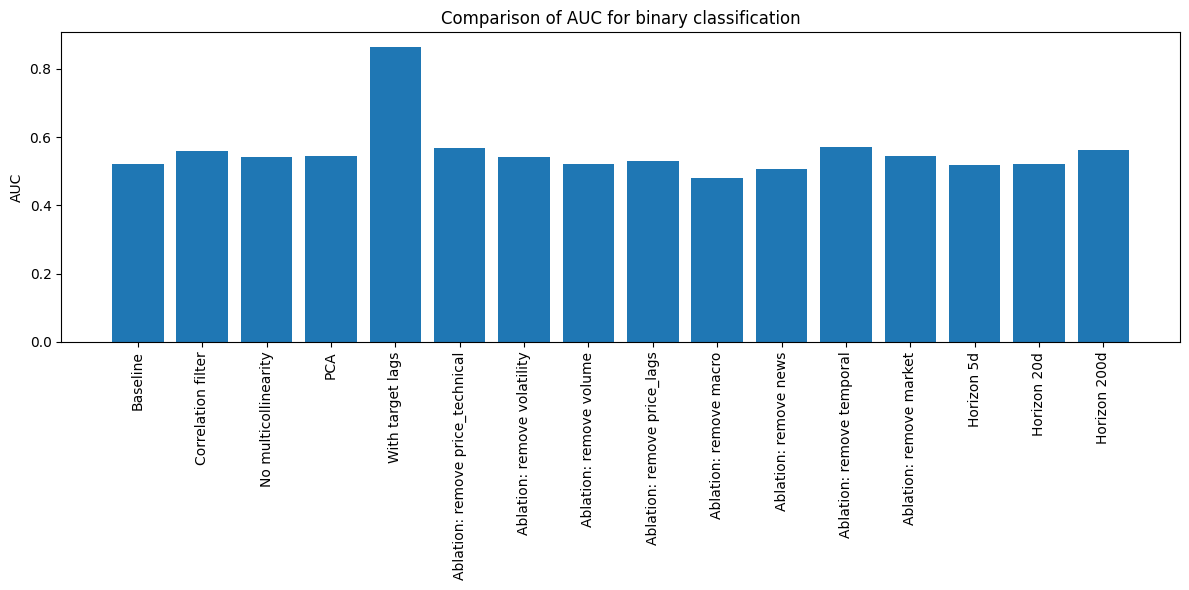

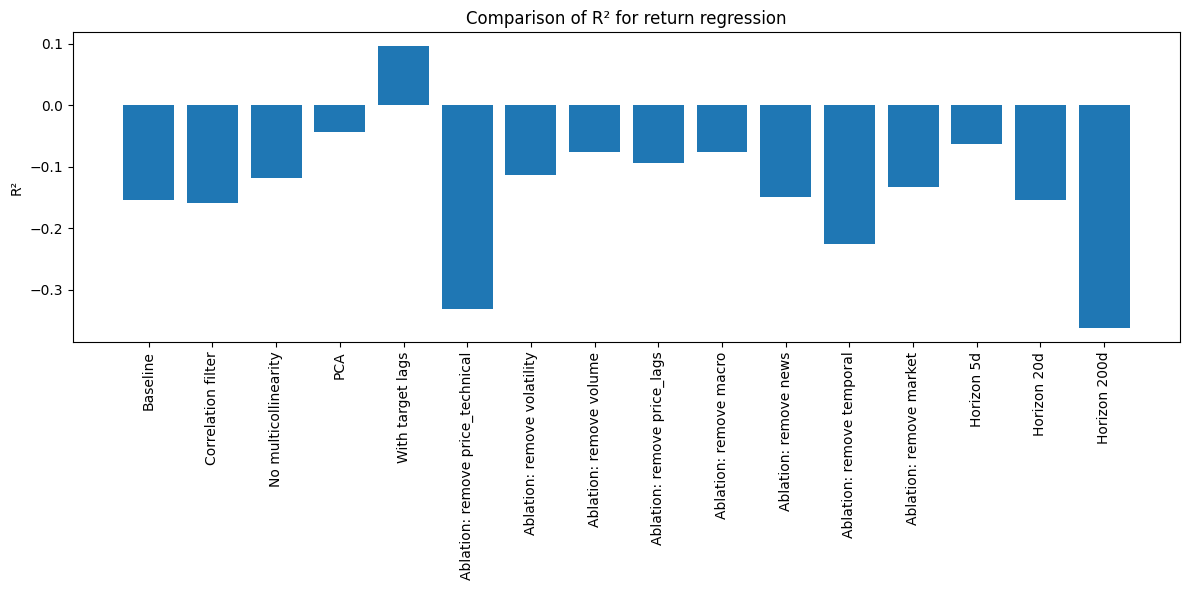

In [13]:
# Собираем результаты
summary_binary = {
    'Baseline': baseline_binary,
    'Correlation filter': corr_binary,
    'No multicollinearity': multicoll_binary,
    'PCA': pca_binary,
    'With target lags': lag_binary,
}
# Добавляем абляцию
for group, res in ablation_results_binary.items():
    summary_binary[f'Ablation: remove {group}'] = res

# Горизонты
for h, res in horizon_results_binary.items():
    summary_binary[f'Horizon {h}d'] = res

df_summary_binary = pd.DataFrame(summary_binary).T
df_summary_binary = df_summary_binary.round(4)
df_summary_binary.to_csv(ARTIFACTS_DIR / "summary_binary.csv")
print("Binary classification results:\n", df_summary_binary)

# Для регрессии
summary_return = {
    'Baseline': baseline_return,
    'Correlation filter': corr_return,
    'No multicollinearity': multicoll_return,
    'PCA': pca_return,
    'With target lags': lag_return,
}
for group, res in ablation_results_return.items():
    summary_return[f'Ablation: remove {group}'] = res
for h, res in horizon_results_return.items():
    summary_return[f'Horizon {h}d'] = res

df_summary_return = pd.DataFrame(summary_return).T
df_summary_return = df_summary_return.round(4)
df_summary_return.to_csv(ARTIFACTS_DIR / "summary_return.csv")
print("\nRegression results:\n", df_summary_return)

# Графики
plt.figure(figsize=(12,6))
auc_vals = df_summary_binary['auc'].dropna()
plt.bar(auc_vals.index, auc_vals.values)
plt.xticks(rotation=90)
plt.ylabel('AUC')
plt.title('Comparison of AUC for binary classification')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "auc_comparison.png", dpi=150)
plt.show()

plt.figure(figsize=(12,6))
r2_vals = df_summary_return['r2'].dropna()
plt.bar(r2_vals.index, r2_vals.values)
plt.xticks(rotation=90)
plt.ylabel('R²')
plt.title('Comparison of R² for return regression')
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "r2_comparison.png", dpi=150)
plt.show()

## Выводы

Анализ полученных результатов позволяет определить:
- Какие группы признаков наиболее значимы (абляция).
- Помогает ли отбор по корреляции и удаление мультиколлинеарности.
- Улучшает ли PCA качество.
- Добавление лагов целевой переменной – если AUC резко возрастает, это может указывать на сильную автокорреляцию, но также и на потенциальный риск переобучения.
- Как влияет горизонт прогноза на качество.

На основе этих экспериментов можно принять решение о финальном наборе признаков для производственной модели.